In [1]:
import pandas as pd
from collections import Counter 
import math
import geopandas as gpd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.dates as mdates
from shapely.geometry import Point
from scipy.stats import chi2_contingency
from scipy.spatial import cKDTree
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from scipy.stats import chi2
from tqdm import tqdm
from esda.moran import Moran


# Lecture des donnees 

In [2]:
df_events = pd.read_csv("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/patients_all_idf_EM.csv", sep = ";")
df_patients = pd.read_csv("Resultats/Excels/patients_FR_IDF_geocoded_adultes_clinique_patho.csv", sep=";")
df_deces = pd.read_csv("../geocodeur/from_hegp/data/data_octobre_2023/date_dc_pseudo.csv", sep = ";")
# df_EM_PM10 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2017/patients_EM_pm10.csv", sep=",")


PM10_2017 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2017/pic_patients_pm10.csv", sep = ";")
PM10_2018 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2018/pic_patients_pm10.csv", sep = ";")
PM10_2019 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2019/pic_patients_pm10.csv", sep = ";")

O3_2017 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2017/pic_patients_O3.csv", sep = ";")
O3_2018 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2018/pic_patients_O3.csv", sep = ";")
O3_2019 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2019/pic_patients_O3.csv", sep = ";")

gdf_idf = gpd.read_file("../geocodeur/from_hegp/data/zones_geographiques/departements/IDF/dpt_idf.shp")




In [28]:
year = [2017,2018,2019]

# preparation des dataframes

In [5]:
#fonction pour convertir les dates en dateframe
def parse_date(date_str):
    for fmt in ('%d/%m/%Y', '%Y-%m-%d %H:%M:%S'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except ValueError:
            pass
    return pd.to_datetime(date_str, errors='coerce')

In [37]:
#conversion des dates des EM en dateframe
df_events['Date_debut'] = df_events['Date_debut'].apply(parse_date)

#extraction des evenements médicaux par année
df_events_2017 = df_events[df_events['Date_debut'].dt.year == 2017]
df_events_2018 = df_events[df_events['Date_debut'].dt.year == 2018]
df_events_2019 = df_events[df_events['Date_debut'].dt.year == 2019]


#conversion des date de dernieres nouvelles en dateframes 
df_deces['date_derniere_nouvelle'] = pd.to_datetime(df_deces['date_derniere_nouvelle'])

#extraction des décès entre 2017 et 2019
pseudo = df_patients[df_patients['pseudo_provisoire'].isin(df_deces['pseudo_provisoire'])]['pseudo_provisoire']
df_deces = df_deces.drop_duplicates(subset='pseudo_provisoire', keep='last')
print(len(df_deces))

df_patients_w_statut= df_patients[df_patients['pseudo_provisoire'].isin(pseudo)].merge(df_deces, on='pseudo_provisoire', how='inner')
print(len(df_patients_w_statut))
patients_dcd = df_patients_w_statut[(df_patients_w_statut['statut_deces']=='oui')&(df_patients_w_statut['date_derniere_nouvelle'].dt.year).isin(year)]
print(f'le nombre de patients decedes: {len(patients_dcd)}')

#extraction des décès par année
patients_dcd_2017 = patients_dcd[patients_dcd['date_derniere_nouvelle'].dt.year == 2017]
patients_dcd_2018 = patients_dcd[patients_dcd['date_derniere_nouvelle'].dt.year == 2018]
patients_dcd_2019 = patients_dcd[patients_dcd['date_derniere_nouvelle'].dt.year == 2019]




#chargement des polluants par année
PM10_2017['date'] = pd.to_datetime(PM10_2017['date'])
PM10_2018['date'] = pd.to_datetime(PM10_2018['date'])
PM10_2019['date'] = pd.to_datetime(PM10_2019['date'])

O3_2017['date'] = pd.to_datetime(O3_2017['date'])
O3_2018['date'] = pd.to_datetime(O3_2018['date'])
O3_2019['date'] = pd.to_datetime(O3_2019['date'])

64012
44765
le nombre de patients decedes: 3990


In [38]:
# Liste des DataFrames des concentrations par année
df_PM10s = [PM10_2017, PM10_2018, PM10_2019]
df_O3s = [O3_2017, O3_2018, O3_2019]

In [39]:
patients_dcd.columns

Index(['Unnamed: 0', 'pseudo_provisoire', 'adresse', 'codepost',
       'nom_commune_postal', 'requete', 'x', 'y', 'score', 'trust_score',
       'street', 'city', 'pc_city', 'ic_city', 'code_dept', 'dept', 'reg',
       'address', 'address_has_num_init', 'address_has_num_geoloc',
       'same_city', 'hostel', 'hosted', 'date_geoloc', 'geometry', 'CODE_IRIS',
       'INSEE_REG', 'CODE_DEPT', 'patient_sexe', 'date_naissance_x', 'centre',
       'ageaudiag', 'cancernum', 'date_diag', 'topo_initiale_cim10',
       'topo_initialelib', 'patho', 'patient_co', 'date_naissance_y',
       'date_derniere_nouvelle', 'statut_deces'],
      dtype='object')

# Definition des seuils de PM10 et O3

In [17]:
# Seuils de concentration pour considérer un pic
seuil_PM10 = 50  # Ajuster selon le contexte réglementaire ou scientifique
seuil_O3 = 180   # Ajuster selon le contexte réglementaire ou scientifique

# Affichage de la distribution des ecarts en jours entre la survenue du pic et la manifestation de l'EM ou le jour du décès pour chaque polluant

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

#fonction qui permet de determiner la date du pic le plus recent precedent l'evenement considéré
def find_most_recent_concentration(event_date, patient_pseudo, df_list, pollutant_col, threshold):
    most_recent_date = None
    for df in df_list:
        patient_data = df[df['pseudo_provisoire'] == patient_pseudo]
        patient_data_before_event = patient_data[(patient_data['date'] <= event_date) & (patient_data[pollutant_col] > threshold)]
        if not patient_data_before_event.empty:
            recent_date = patient_data_before_event['date'].max()
            if most_recent_date is None or recent_date > most_recent_date:
                most_recent_date = recent_date
    return most_recent_date

#fonction permettant de calculer l'ecart en jours entre la date du pic le plus recent et la date de l'evenement considere
def plot_delays(df_events, date_col, df_PM10s, df_O3s, seuil_PM10, seuil_O3, title_PM10, title_O3):
    delays_PM10 = []
    delays_O3 = []

    for _, event in df_events.iterrows():
        event_date = event[date_col]
        patient_pseudo = event['pseudo_provisoire']
        
        # recuperation de la date du pic de pm10 précedent l'evenement
        recent_PM10_date = find_most_recent_concentration(event_date, patient_pseudo, df_PM10s, 'PM10', seuil_PM10)
        
        # recuperation de la date du pic d'o3 precedent l'evenement
        recent_O3_date = find_most_recent_concentration(event_date, patient_pseudo, df_O3s, 'O3', seuil_O3)
        
        # calcul de l'ecart entre pic de pm10 et l'evenement
        if recent_PM10_date:
            delay_PM10 = (event_date - recent_PM10_date).days
            if delay_PM10 <= 365:  # on limite la recherche a 365 jours maximum precedent l'evenement
                delays_PM10.append(delay_PM10)
        
        # calcul de l'ecart entre pic d'O3 et la date de l'evenement
        if recent_O3_date:
            delay_O3 = (event_date - recent_O3_date).days
            if delay_O3 <= 365:  # on limite la recherche a 365 jours maximum precedent l'evenement
                delays_O3.append(delay_O3)

    # histogramme des ecarts calcules pour le pic de PM10
    plt.figure(figsize=(7, 6))
    n, bins, patches = plt.hist(delays_PM10, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
    plt.xlabel('Delai PM10 (jours)')
    plt.ylabel('Frequence')
    plt.title(title_PM10)
    plt.xlim(0, 365)

    # ajout des quartile
    if delays_PM10:
        q25_PM10 = pd.Series(delays_PM10).quantile(0.25)
        q50_PM10 = pd.Series(delays_PM10).quantile(0.50)
        q75_PM10 = pd.Series(delays_PM10).quantile(0.75)
        plt.axvline(q25_PM10, color='blue', linestyle='dashed', linewidth=1, label=f'25e Percentile: {q25_PM10:.0f} jours')
        plt.axvline(q50_PM10, color='green', linestyle='dashed', linewidth=1, label=f'Médiane: {q50_PM10:.0f} jours')
        plt.axvline(q75_PM10, color='red', linestyle='dashed', linewidth=1, label=f'75e Percentile: {q75_PM10:.0f} jours')
        plt.legend()

    plt.show()

    # Histogramlme des ecarts pour le pic d'O3
    plt.figure(figsize=(7, 6))
    n, bins, patches = plt.hist(delays_O3, bins=30, edgecolor='black', color='salmon', alpha=0.7)
    plt.xlabel('Delai O3 (jours)')
    plt.ylabel('Frequence')
    plt.title(title_O3)
    plt.xlim(0, 365)

    # Ajout des quartiles
    if delays_O3:
        q25_O3 = pd.Series(delays_O3).quantile(0.25)
        q50_O3 = pd.Series(delays_O3).quantile(0.50)
        q75_O3 = pd.Series(delays_O3).quantile(0.75)
        plt.axvline(q25_O3, color='blue', linestyle='dashed', linewidth=1, label=f'25e Percentile: {q25_O3:.0f} jours')
        plt.axvline(q50_O3, color='green', linestyle='dashed', linewidth=1, label=f'Médiane: {q50_O3:.0f} jours')
        plt.axvline(q75_O3, color='red', linestyle='dashed', linewidth=1, label=f'75e Percentile: {q75_O3:.0f} jours')
        plt.legend()

    plt.show()




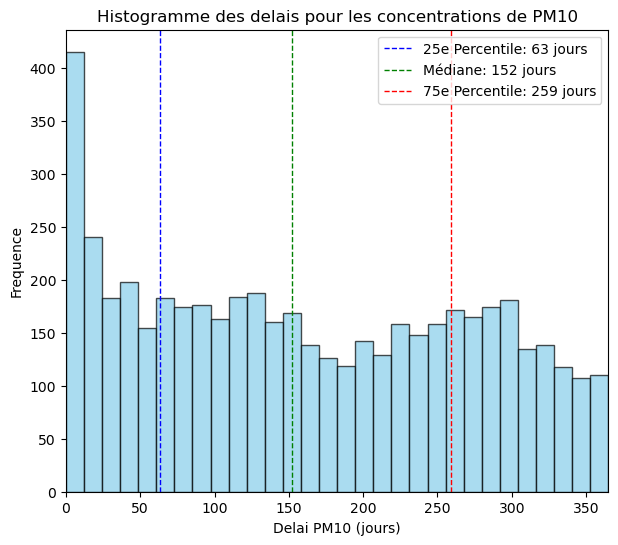

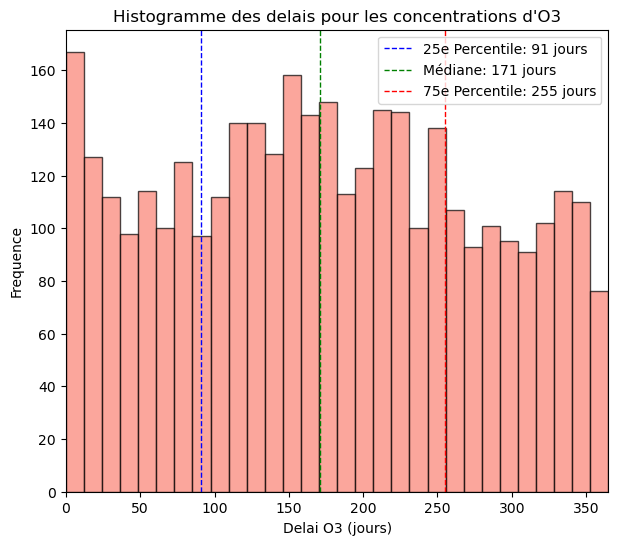

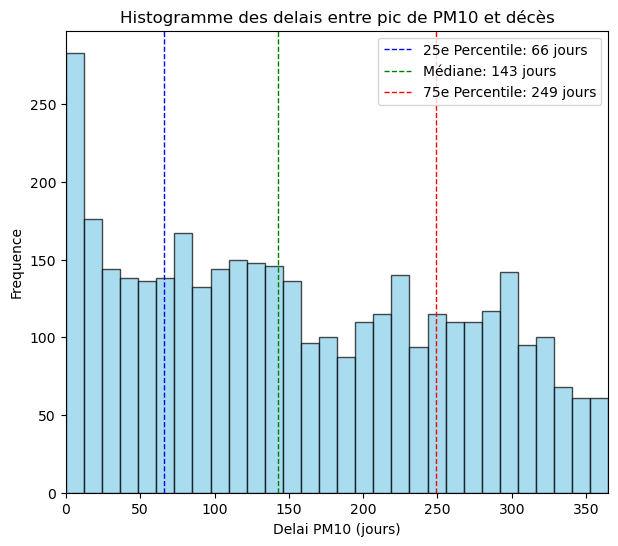

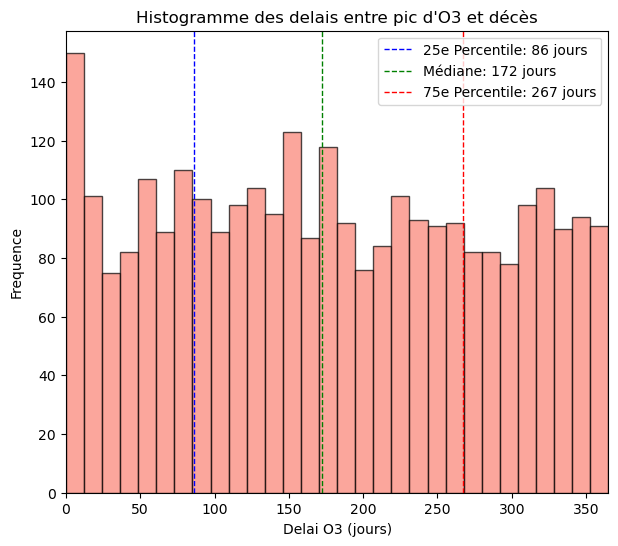

In [19]:
plot_delays(df_events, 'Date_debut', df_PM10s, df_O3s, seuil_PM10, seuil_O3, 'Histogramme des delais pour les concentrations de PM10', 'Histogramme des delais pour les concentrations d\'O3')

plot_delays(patients_dcd, 'date_derniere_nouvelle', df_PM10s, df_O3s, seuil_PM10, seuil_O3, 'Histogramme des delais entre pic de PM10 et décès', 'Histogramme des delais entre pic d\'O3 et décès')

# Zoom sur le 1er quartile: Analyse des evenements medicaux ou deces survenant dans un delai x jours  (x etant le premier quartile)

In [20]:
df_events_list = [df_events_2017, df_events_2018, df_events_2019]
patients_dcd_list = [patients_dcd_2017, patients_dcd_2018, patients_dcd_2019]
years = [2017, 2018, 2019]
delai_pm10 = 92 #(1 mois)
delai_o3 = 92  #(1 mois)


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_nearest_pic(row, list_pollutants, seuil, concentration_col, delai, date_col):
    patient_id = row['pseudo_provisoire']
    date_ref = row[date_col]

    nearest_pic_date = np.nan
    
    for df_pollutant in list_pollutants:
        # Filtrer les données du patient spécifique
        df_patient = df_pollutant[df_pollutant['pseudo_provisoire'] == patient_id]
        
        # Vérifier si le DataFrame est vide
        if df_patient.empty:
            continue

        # Trouver les pics de pollution au-dessus du seuil
        df_patient_pic = df_patient[df_patient[concentration_col] > seuil]
        
        # Vérifier si le DataFrame est vide après filtrage par seuil
        if df_patient_pic.empty:
            continue
        
        # Filtrer les pics de pollution dans le délai spécifié
        df_patient_pic = df_patient_pic[(df_patient_pic['date'] <= date_ref) & 
                                         (df_patient_pic['date'] >= (date_ref - pd.Timedelta(days=delai)))]
        
        # Vérifier si le DataFrame est vide après filtrage par délai
        if df_patient_pic.empty:
            continue
        
        # Trouver la date du pic le plus proche
        pic_date = df_patient_pic['date'].max()
        
        if pd.isna(nearest_pic_date) or (pic_date > nearest_pic_date):
            nearest_pic_date = pic_date

    return nearest_pic_date

def analyze_event_or_death_distribution(df_events_or_deaths, list_pollutants, seuil, pollutant_col, delai, date_col, label, year):
    # Assurez-vous que la colonne de date est en format datetime
    df_events_or_deaths[date_col] = pd.to_datetime(df_events_or_deaths[date_col])
    
    for df_pollutant in list_pollutants:
        df_pollutant['date'] = pd.to_datetime(df_pollutant['date'])
    
    # Trouver la date du pic le plus proche
    df_events_or_deaths[f'nearest_{pollutant_col}_pic_date'] = df_events_or_deaths.apply(
        lambda row: find_nearest_pic(row, list_pollutants, seuil, pollutant_col, delai, date_col), axis=1
    )
    
    # Calculer les jours depuis le pic
    df_events_or_deaths[f'days_since_{pollutant_col}_pic'] = (df_events_or_deaths[date_col] - df_events_or_deaths[f'nearest_{pollutant_col}_pic_date']).dt.days
    
    # Filtrer les événements avec des dates de pic valides
    df_filtered = df_events_or_deaths.dropna(subset=[f'nearest_{pollutant_col}_pic_date'])

    # Comptabiliser les jours depuis le pic
    counts = df_filtered[f'days_since_{pollutant_col}_pic'].value_counts().sort_index()

    # Calculer le ratio des événements dans le délai spécifié
    events_within_delay = df_filtered[(df_filtered[f'days_since_{pollutant_col}_pic'] >= 0) &
                                      (df_filtered[f'days_since_{pollutant_col}_pic'] <= delai)]
    num_events_within_delay = len(events_within_delay)
    total_events = len(df_events_or_deaths)
    ratio = (num_events_within_delay / total_events) * 100 if total_events != 0 else 0

    # Afficher les résultats
    print(f"{label} - Ratio des événements associés au pic de {pollutant_col} dans un délai de 0 à {delai} jours: {ratio:.2f}%")
    print(f'Nombre total d\'événements pour {label}: {total_events}')
    print(f'Nombre d\'événements dont le pic de {pollutant_col} survient dans {delai} jours avant: {num_events_within_delay}')

    # Tracer la distribution
    plt.figure(figsize=(10, 6))
    color = 'skyblue' if pollutant_col == 'PM10' else 'lightcoral'
    bars = plt.bar(counts.index, counts.values, color=color, edgecolor='black', alpha=0.7, width=1)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')

    # Marquer les barres correspondant au pic le plus fréquent
    max_days = counts.idxmax() if not counts.empty else 0
    for bar in bars:
        if bar.get_x() <= max_days < bar.get_x() + bar.get_width():
            bar.set_color('red')

    plt.xlabel(f'Durée (jours) entre le pic de {pollutant_col} et {label}')
    plt.ylabel('Nombre de cas')
    plt.title(f'Distribution de la durée entre le pic de {pollutant_col} et {label} pour l\'année {year}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



Analyse des evènements pour l'année 2017:
les événements médicaux - Ratio des événements associés au pic de PM10 dans un délai de 0 à 92 jours: 30.61%
Nombre total d'événements pour les événements médicaux: 1692
Nombre d'événements dont le pic de PM10 survient dans 92 jours avant: 518


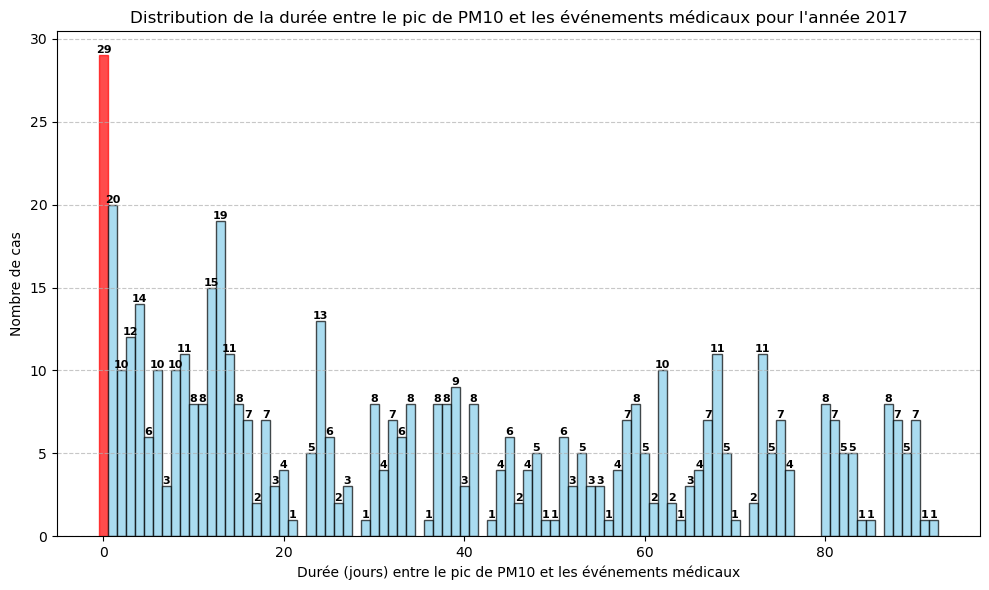

les événements médicaux - Ratio des événements associés au pic de O3 dans un délai de 0 à 92 jours: 22.28%
Nombre total d'événements pour les événements médicaux: 1692
Nombre d'événements dont le pic de O3 survient dans 92 jours avant: 377


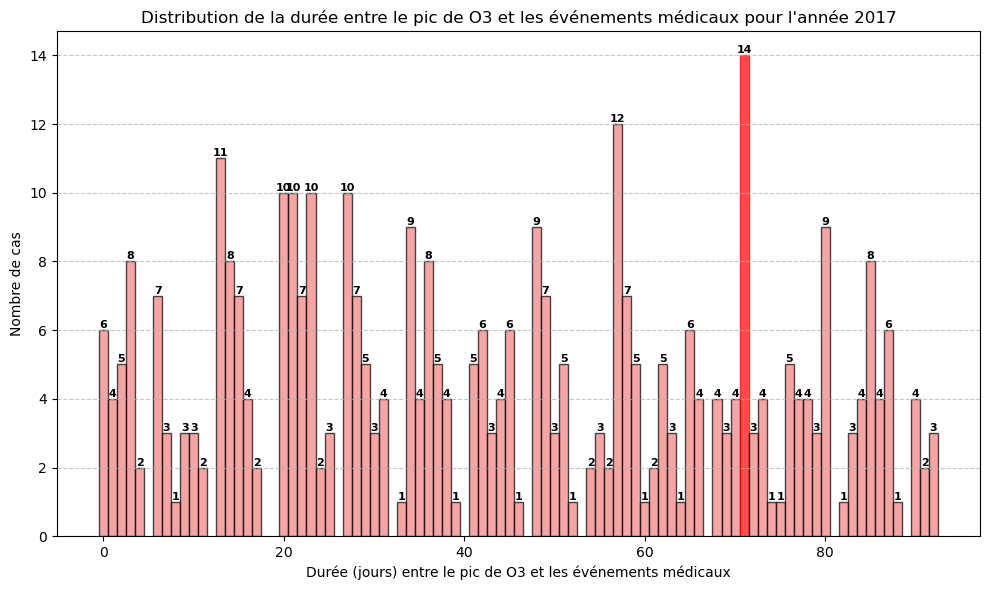


Analyse des evènements pour l'année 2018:
les événements médicaux - Ratio des événements associés au pic de PM10 dans un délai de 0 à 92 jours: 23.30%
Nombre total d'événements pour les événements médicaux: 1528
Nombre d'événements dont le pic de PM10 survient dans 92 jours avant: 356


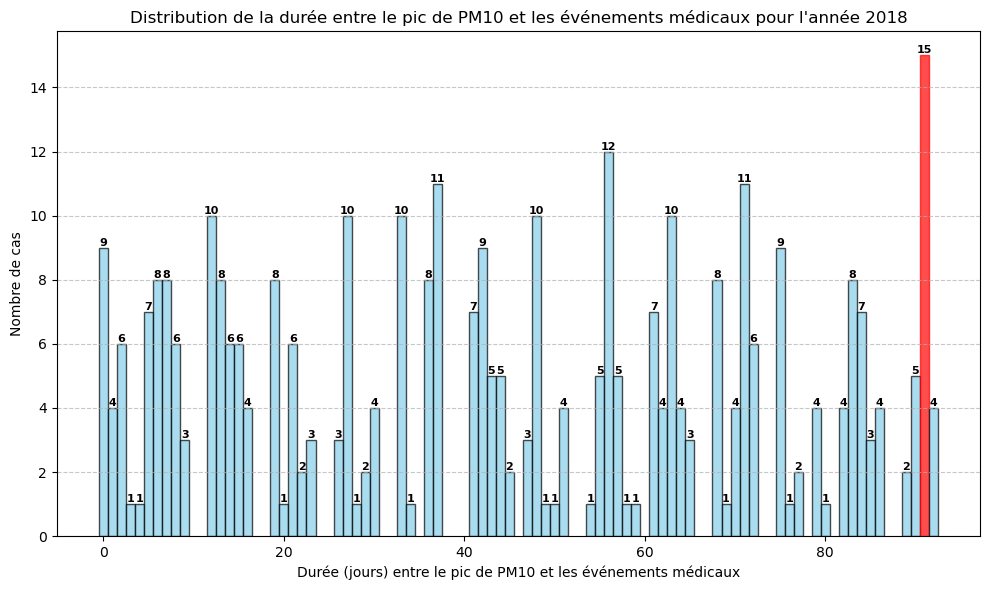

les événements médicaux - Ratio des événements associés au pic de O3 dans un délai de 0 à 92 jours: 27.16%
Nombre total d'événements pour les événements médicaux: 1528
Nombre d'événements dont le pic de O3 survient dans 92 jours avant: 415


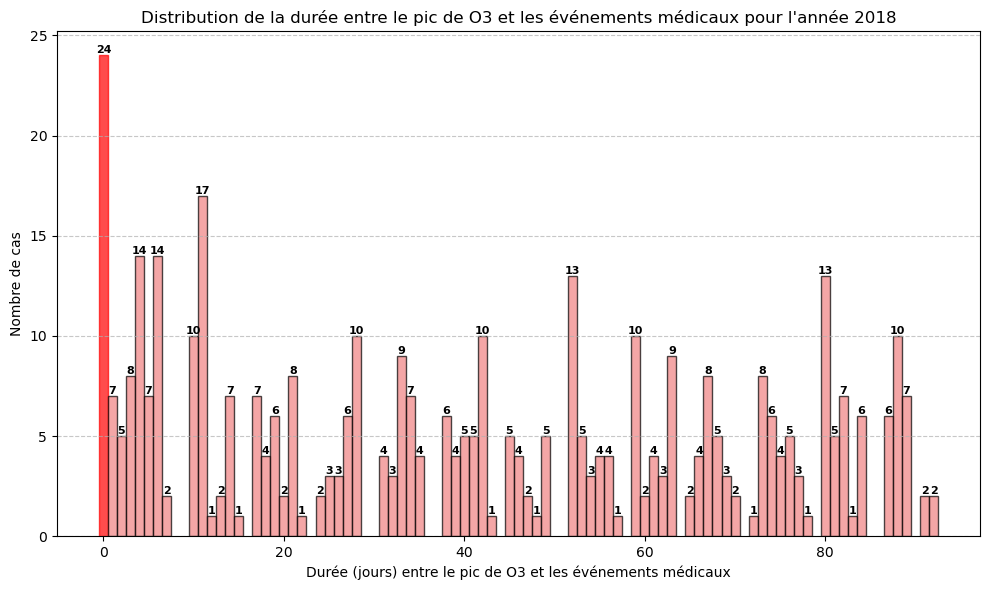


Analyse des evènements pour l'année 2019:
les événements médicaux - Ratio des événements associés au pic de PM10 dans un délai de 0 à 92 jours: 36.18%
Nombre total d'événements pour les événements médicaux: 1896
Nombre d'événements dont le pic de PM10 survient dans 92 jours avant: 686


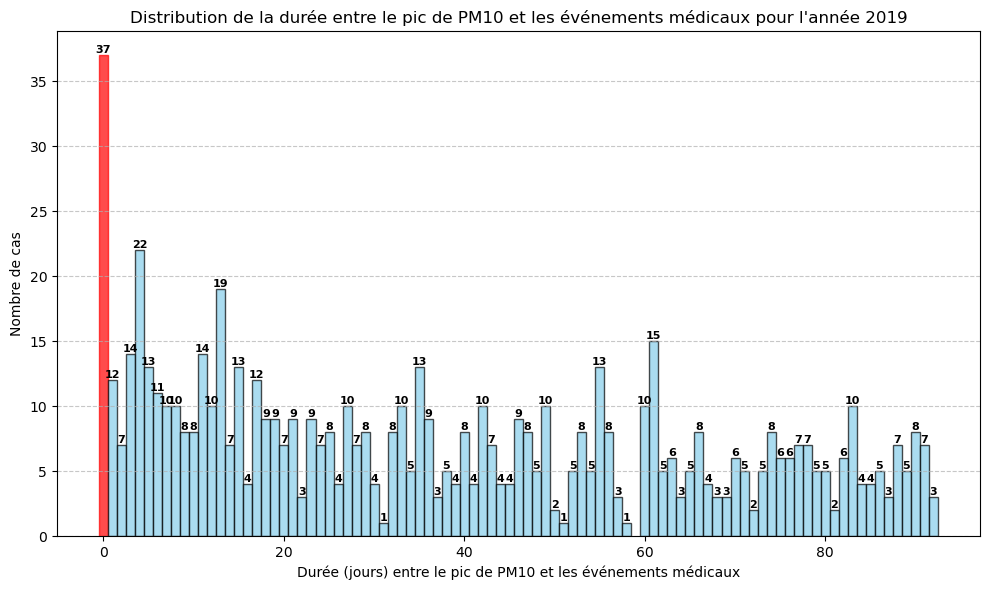

les événements médicaux - Ratio des événements associés au pic de O3 dans un délai de 0 à 92 jours: 5.59%
Nombre total d'événements pour les événements médicaux: 1896
Nombre d'événements dont le pic de O3 survient dans 92 jours avant: 106


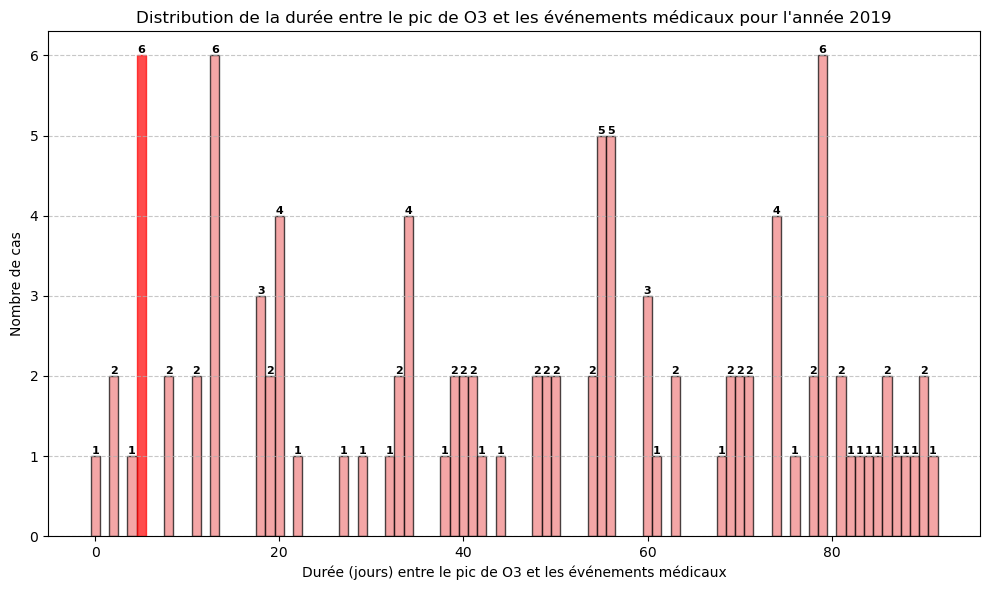


Analyse des décès pour l'année 2017:
les décès - Ratio des événements associés au pic de PM10 dans un délai de 0 à 92 jours: 29.46%
Nombre total d'événements pour les décès: 1120
Nombre d'événements dont le pic de PM10 survient dans 92 jours avant: 330


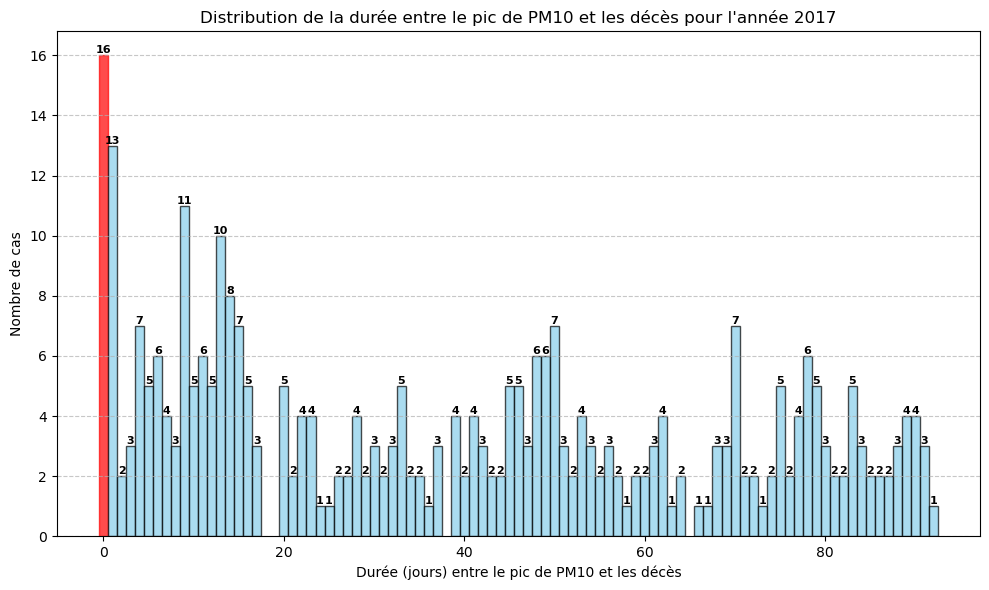

les décès - Ratio des événements associés au pic de O3 dans un délai de 0 à 92 jours: 25.45%
Nombre total d'événements pour les décès: 1120
Nombre d'événements dont le pic de O3 survient dans 92 jours avant: 285


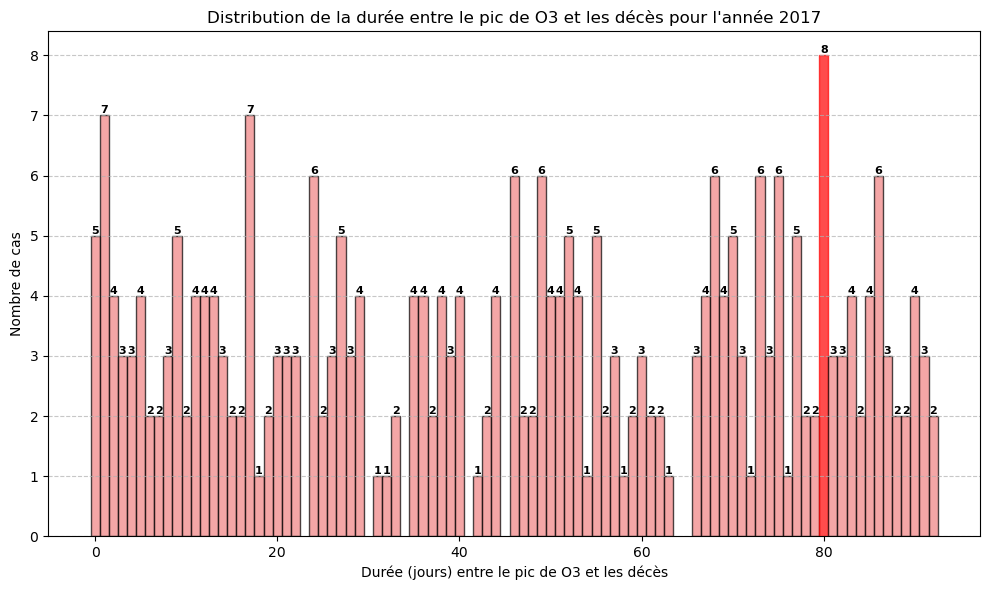


Analyse des décès pour l'année 2018:
les décès - Ratio des événements associés au pic de PM10 dans un délai de 0 à 92 jours: 26.51%
Nombre total d'événements pour les décès: 1373
Nombre d'événements dont le pic de PM10 survient dans 92 jours avant: 364


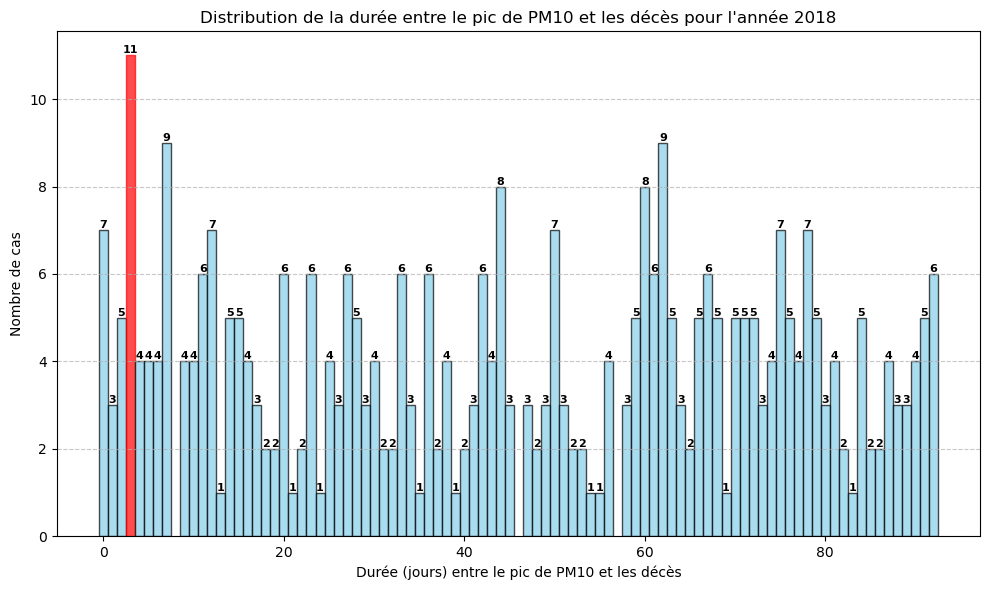

les décès - Ratio des événements associés au pic de O3 dans un délai de 0 à 92 jours: 28.91%
Nombre total d'événements pour les décès: 1373
Nombre d'événements dont le pic de O3 survient dans 92 jours avant: 397


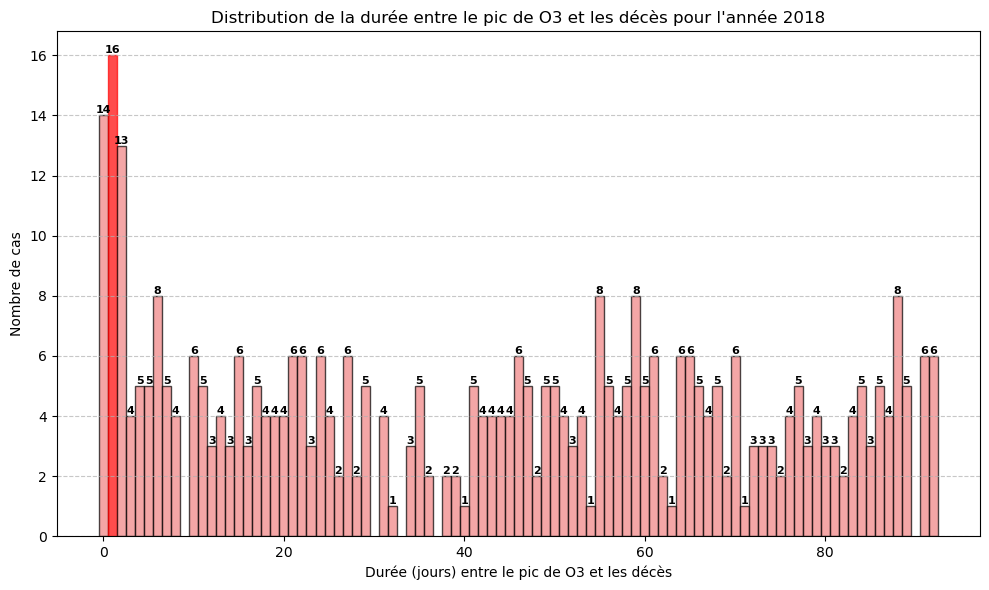


Analyse des décès pour l'année 2019:
les décès - Ratio des événements associés au pic de PM10 dans un délai de 0 à 92 jours: 37.61%
Nombre total d'événements pour les décès: 1497
Nombre d'événements dont le pic de PM10 survient dans 92 jours avant: 563


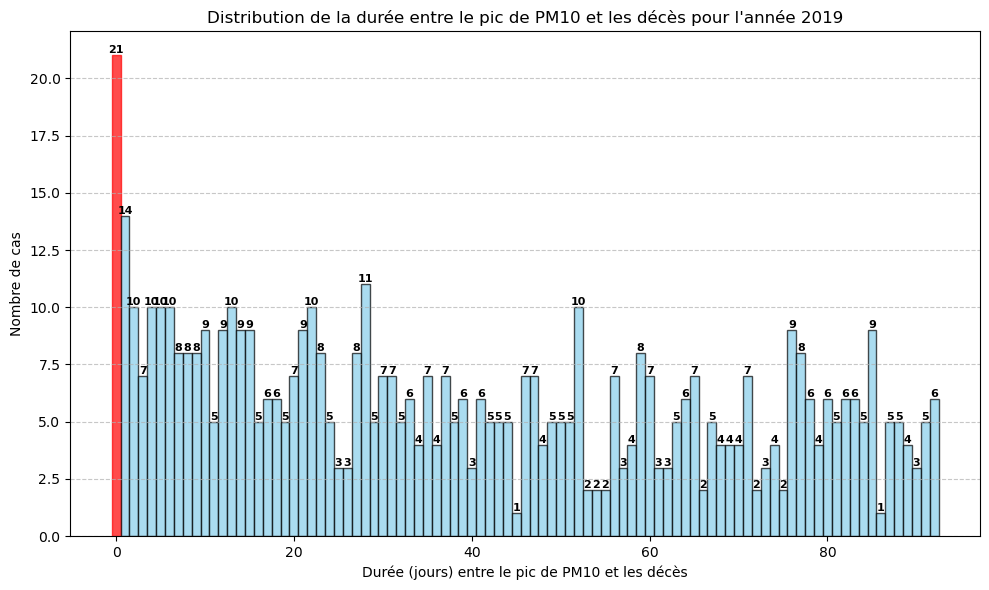

les décès - Ratio des événements associés au pic de O3 dans un délai de 0 à 92 jours: 6.48%
Nombre total d'événements pour les décès: 1497
Nombre d'événements dont le pic de O3 survient dans 92 jours avant: 97


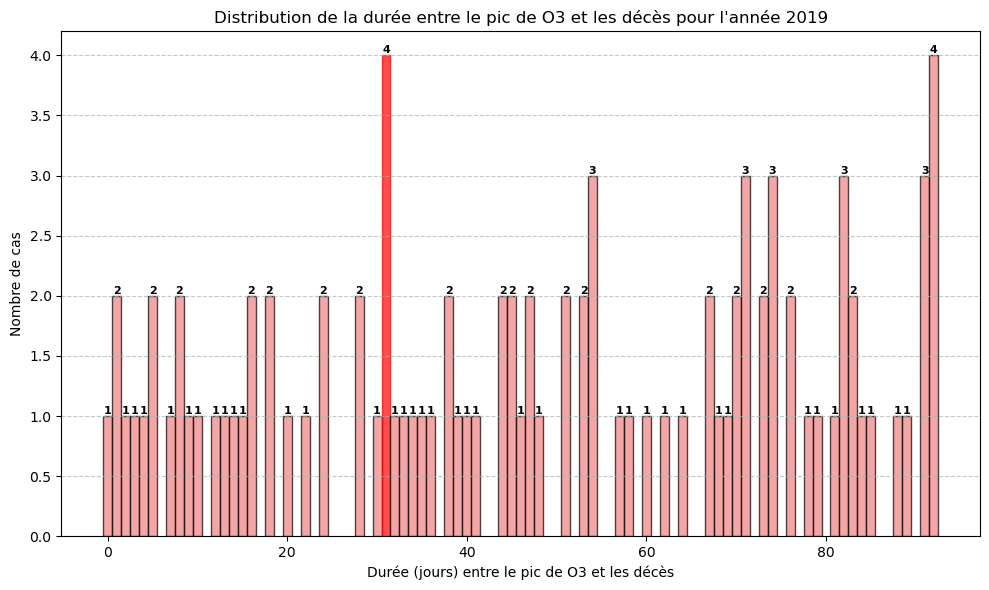

In [22]:
# Application de la fonction pour chaque année
for df_events, year in zip(df_events_list, years):
    print(f"\nAnalyse des evènements pour l'année {year}:")
    analyze_event_or_death_distribution(df_events, df_PM10s, seuil_PM10, 'PM10', delai_pm10, 'Date_debut', 'les événements médicaux',year)
    analyze_event_or_death_distribution(df_events, df_O3s, seuil_O3, 'O3', delai_o3, 'Date_debut', 'les événements médicaux',year)


# Application de la fonction pour chaque année
for patients_dcd, year in zip(patients_dcd_list, years):
    print(f"\nAnalyse des décès pour l'année {year}:")
    analyze_event_or_death_distribution(patients_dcd, df_PM10s, seuil_PM10, 'PM10', delai_pm10, 'date_derniere_nouvelle', 'les décès', year)
    analyze_event_or_death_distribution(patients_dcd, df_O3s, seuil_O3, 'O3', delai_o3, 'date_derniere_nouvelle', 'les décès', year)

In [23]:
PM10s = pd.concat([PM10_2017,PM10_2018,PM10_2019])
O3s = pd.concat([O3_2017, O3_2018, O3_2019])

In [24]:
def analyze_pics_and_dates(df_patients_w_statut, df_PM10s, seuil, delai, date_col, pollutant_col, status_col='statut_deces'):
    # Convertir les colonnes de date en datetime
    df_patients_w_statut[date_col] = pd.to_datetime(df_patients_w_statut[date_col])
    df_PM10s['date'] = pd.to_datetime(df_PM10s['date'])
    
    # Préparer la liste des résultats
    results_list = []
    
    # Parcourir chaque patient
    for _, patient_row in df_patients_w_statut.iterrows():
        patient_id = patient_row['pseudo_provisoire']
        last_update_date = patient_row[date_col]
        is_deceased = patient_row[status_col] == 'oui'
        
        # Définir la période d'intérêt
        start_date = last_update_date - pd.Timedelta(days=delai)
        
        # Filtrer les données de PM10 pour le patient
        df_patient_PM10 = df_PM10s[df_PM10s['pseudo_provisoire'] == patient_id]
        
        # Filtrer les données de PM10 dans la période d'intérêt et au-dessus du seuil
        df_filtered = df_patient_PM10[(df_patient_PM10['date'] >= start_date) & 
                                      (df_patient_PM10['date'] <= last_update_date) & 
                                      (df_patient_PM10[pollutant_col] >= seuil)]
        
        # Compter les pics et lister les jours de pic
        nombre_pics = len(df_filtered)
        dates_pics = df_filtered['date'].tolist()
        
        # Ajouter les résultats pour ce patient
        results_list.append({
            'pseudo_provisoire': patient_id,
            status_col: is_deceased,
            f'nombre_pics_{pollutant_col}': nombre_pics,
            f'dates_pics_{pollutant_col}': dates_pics
        })
    
    # Convertir les résultats en DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Fusionner les résultats avec le DataFrame des patients
    final_results = df_patients_w_statut.merge(results_df, on='pseudo_provisoire', how='left')
    
    # # Remplacer les NaN dans nombre_pics par 0 après la fusion
    # final_results[f'nombre_pics_{pollutant_col}'] = final_results[f'nombre_pics_{pollutant_col}'].fillna(0).astype(int)
    
    # # Convertir les dates de pics en chaînes de caractères
    # final_results[f'dates_pics_{pollutant_col}'] = final_results[f'dates_pics_{pollutant_col}'].apply(lambda x: ', '.join(map(str, x)) if isinstance(x, list) else '')
    
    return final_results


In [25]:
resultats_PM10 = analyze_pics_and_dates(
    df_patients_w_statut, 
    PM10s, 
    seuil=40, 
    delai=delai_pm10, 
    date_col='date_derniere_nouvelle', 
    pollutant_col='PM10', 
    status_col='statut_deces'
)


KeyboardInterrupt: 

In [ ]:
resultats_O3 = analyze_pics_and_dates(
    df_patients_w_statut, 
    O3s, 
    seuil=180, 
    delai=delai_o3, 
    date_col='date_derniere_nouvelle', 
    pollutant_col='O3', 
    status_col='statut_deces'
)


In [ ]:
resultats_PM10['dcd_2017_2019'] = resultats_PM10['pseudo_provisoire'].isin(patients_dcd['pseudo_provisoire'])

In [ ]:
resultats_O3['dcd_2017_2019'] = resultats_O3['pseudo_provisoire'].isin(patients_dcd['pseudo_provisoire'])

In [ ]:
resultats_O3 = resultats_O3.drop(columns=['date_naissance_y', 'statut_deces_y'])
# resultats_PM10 = resultats_PM10.drop(columns=['date_naissance_y', 'statut_deces_y'])

In [ ]:
resultats_O3.columns

Index(['Unnamed: 0', 'pseudo_provisoire', 'adresse', 'codepost',
       'nom_commune_postal', 'requete', 'x', 'y', 'score', 'trust_score',
       'street', 'city', 'pc_city', 'ic_city', 'code_dept', 'dept', 'reg',
       'address', 'address_has_num_init', 'address_has_num_geoloc',
       'same_city', 'hostel', 'hosted', 'date_geoloc', 'geometry', 'CODE_IRIS',
       'INSEE_REG', 'CODE_DEPT', 'patient_sexe', 'date_naissance', 'centre',
       'ageaudiag', 'cancernum', 'date_diag', 'topo_initiale_cim10',
       'topo_initialelib', 'patho', 'patient_co', 'date_derniere_nouvelle',
       'statut_deces', 'start_date', 'nombre_pics_O3', 'dates_pics_O3',
       'dcd_2017_2019', 'pic_O3', 'const'],
      dtype='object')

In [ ]:
resultats_O3 = resultats_O3.rename(columns = {
    'date_naissance_x':'date_naissance',
    'statut_deces_x' : 'statut_deces'
    })

# resultats_PM10 = resultats_PM10.rename(columns = {
#     'date_naissance_x':'date_naissance',
#     'statut_deces_x' : 'statut_deces'
#     })

In [ ]:
resultats_O3.columns

Index(['Unnamed: 0', 'pseudo_provisoire', 'adresse', 'codepost',
       'nom_commune_postal', 'requete', 'x', 'y', 'score', 'trust_score',
       'street', 'city', 'pc_city', 'ic_city', 'code_dept', 'dept', 'reg',
       'address', 'address_has_num_init', 'address_has_num_geoloc',
       'same_city', 'hostel', 'hosted', 'date_geoloc', 'geometry', 'CODE_IRIS',
       'INSEE_REG', 'CODE_DEPT', 'patient_sexe', 'date_naissance', 'centre',
       'ageaudiag', 'cancernum', 'date_diag', 'topo_initiale_cim10',
       'topo_initialelib', 'patho', 'patient_co', 'date_derniere_nouvelle',
       'statut_deces', 'start_date', 'nombre_pics_O3', 'dates_pics_O3',
       'dcd_2017_2019'],
      dtype='object')

In [ ]:
resultats_O3['pic_O3']= resultats_O3['nombre_pics_O3'] > 0
# resultats_PM10['pic_PM10']= resultats_PM10['nombre_pics_PM10'] > 0

In [ ]:
resultats_O3.to_csv('Resultats/Excels/patients_pic_O3_180.csv', sep = ';')
# resultats_PM10.to_csv(f'Resultats/Excels/patients_pic_PM10_40.csv', sep = ';')

# TEST DE CORRELATION ENTRE PIC PM10 ET LES DECES

In [63]:
pic_pm10_50 = pd.read_csv('Resultats/Excels/patients_pic_pm10.csv', sep = ';')
pic_O3_180 = pd.read_csv('Resultats/Excels/patients_pic_O3_180.csv', sep = ';')
pic_pm10_40 = pd.read_csv('Resultats/Excels/patients_pic_pm10_40.csv', sep = ';')
pic_O3_140 = pd.read_csv('Resultats/Excels/patients_pic_O3_140.csv', sep = ';')

In [ ]:
from scipy.stats import chi2
# Créer une table de contingence
contingency_table = pd.crosstab(resultats_O3['dcd_2017_2019'], resultats_O3['pic_O3'])

# Afficher la table de contingence
print("Table de contingence:")
print(contingency_table)

# Effectuer le test de chi-carré
chi2_stat, p, dof, expected = stats.chi2_contingency(contingency_table)

# Afficher les résultats
print(f"\nTest de chi-carré:")
print(f"Chi2: {chi2_stat}")
print(f"p-value: {p}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected)

# Interprétation des résultats
alpha = 0.05


# Calcul de la valeur critique
valeur_critique = chi2.ppf(1 - alpha, dof)

# Affichage des résultats
print(f"Pour un niveau de signification de {alpha * 100}%, la valeur critique de chi2 est: {valeur_critique:.2f}")

# Tester si la statistique de chi2 observée dépasse la valeur critique
if chi2_stat > valeur_critique:
    print("La statistique chi2 observée dépasse la valeur critique, on rejette l'hypothèse nulle. \nConclusion: Il y a une relation significative entre la présence d'un pic de pollution et la manifestation de l'événement médical (rejeter H0).")
else:
    print("La statistique chi2 observée ne dépasse pas la valeur critique, on ne rejette pas l'hypothèse nulle. \nConclusion: Il n'y a pas de relation significative entre la présence d'un pic de pollution et la manifestation de l'événement médical (ne pas rejeter H0).")

Table de contingence:
pic_O3         False  True 
dcd_2017_2019              
False          39601   1174
True            3211    779

Test de chi-carré:
Chi2: 2409.1613938533387
p-value: 0.0
Degrees of Freedom: 1
Expected Frequencies:
[[38996.07505864  1778.92494136]
 [ 3815.92494136   174.07505864]]
Pour un niveau de signification de 5.0%, la valeur critique de chi2 est: 3.84
La statistique chi2 observée dépasse la valeur critique, on rejette l'hypothèse nulle. 
Conclusion: Il y a une relation significative entre la présence d'un pic de pollution et la manifestation de l'événement médical (rejeter H0).


In [ ]:
import statsmodels.api as sm

# Ajouter une constante pour l'interception
resultats_O3['const'] = 1


# Modèle de régression logistique
logit_model = sm.Logit(resultats_O3['dcd_2017_2019'], resultats_O3[['const', 'nombre_pics_O3']])
result = logit_model.fit()

# Résumé des résultats
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.289141
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          dcd_2017_2019   No. Observations:                44765
Model:                          Logit   Df Residuals:                    44763
Method:                           MLE   Df Model:                            1
Date:                Tue, 13 Aug 2024   Pseudo R-squ.:                 0.03788
Time:                        15:30:48   Log-Likelihood:                -12943.
converged:                       True   LL-Null:                       -13453.
Covariance Type:            nonrobust   LLR p-value:                1.210e-223
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.4465      0.018   -138.682      0.000      -2.481      -2.412
nombre_pics_O3   

In [ ]:
# Ajouter une constante pour l'interception
resultats_PM10['const'] = 1


# Modèle de régression logistique
logit_model = sm.Logit(resultats_PM10['dcd_2017_2019'], resultats_PM10[['const', 'nombre_pics_PM10']])
result = logit_model.fit()

# Résumé des résultats
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.274971
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          dcd_2017_2019   No. Observations:                44765
Model:                          Logit   Df Residuals:                    44763
Method:                           MLE   Df Model:                            1
Date:                Tue, 13 Aug 2024   Pseudo R-squ.:                 0.08503
Time:                        14:00:02   Log-Likelihood:                -12309.
converged:                       True   LL-Null:                       -13453.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.6440      0.019   -136.049      0.000      -2.682      -2.606
nombre_pics

# NOMBRE DE DECES EN FONCTION DU NOMBRE DE PIC

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

def plot_deces_pic(df, col_pic, statut_deces):
    # Convertir la colonne en numérique
    df[col_pic] = pd.to_numeric(df[col_pic], errors='coerce')

    # Assurer que la colonne statut_deces est en booléen
    df[statut_deces] = df[statut_deces].astype(bool)
    dcd = df[df[statut_deces] == True]

    # Calculer le nombre de décès pour chaque nombre de pics
    death_counts = dcd.groupby(col_pic).size()

    # Convertir en DataFrame pour faciliter la visualisation
    death_counts_df = death_counts.reset_index(name='nombre_de_deces')

    # Créer une figure avec un seul axe
    plt.figure(figsize=(12, 8))

    # Créer un histogramme avec matplotlib
    bars = plt.bar(death_counts_df[col_pic], death_counts_df['nombre_de_deces'], color='steelblue', alpha=0.7, edgecolor='black')

    # Ajouter les valeurs au-dessus de chaque barre
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, str(int(height)), ha='center', va='bottom', fontsize=10, color='black')

    # Préparer les données pour la courbe de tendance lissée
    x_smooth = np.linspace(death_counts_df[col_pic].min(), death_counts_df[col_pic].max(), 1000)
    spline = make_interp_spline(death_counts_df[col_pic], death_counts_df['nombre_de_deces'])
    y_smooth = spline(x_smooth)

    # Tracer la courbe de tendance
    plt.plot(x_smooth, y_smooth, color='crimson', linewidth=2.5, label='Courbe de tendance')

    # Paramétrer les axes et les titres
    plt.xlabel(f'Nombre de {col_pic}')
    plt.ylabel('Nombre de Décès')
    plt.title(f'Nombre de Décès en Fonction du Nombre de {col_pic}')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


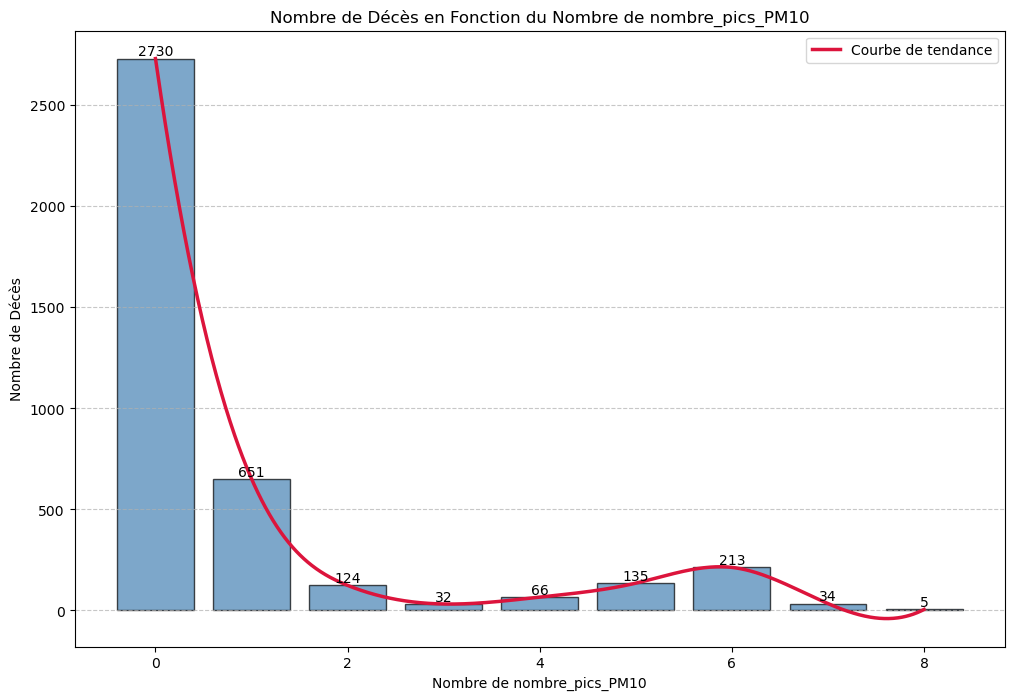

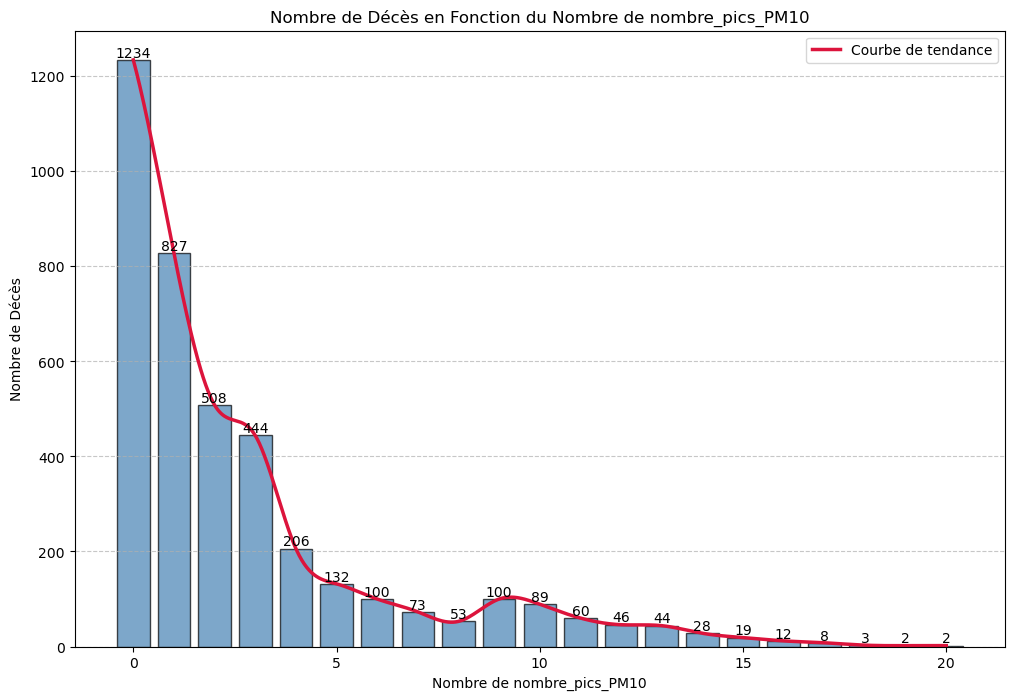

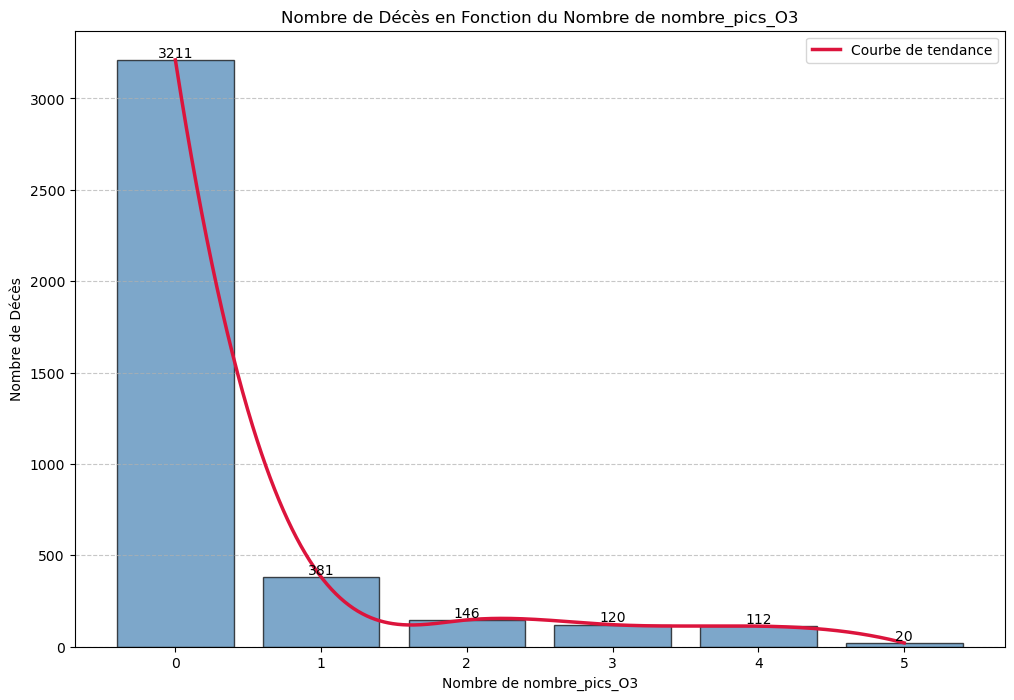

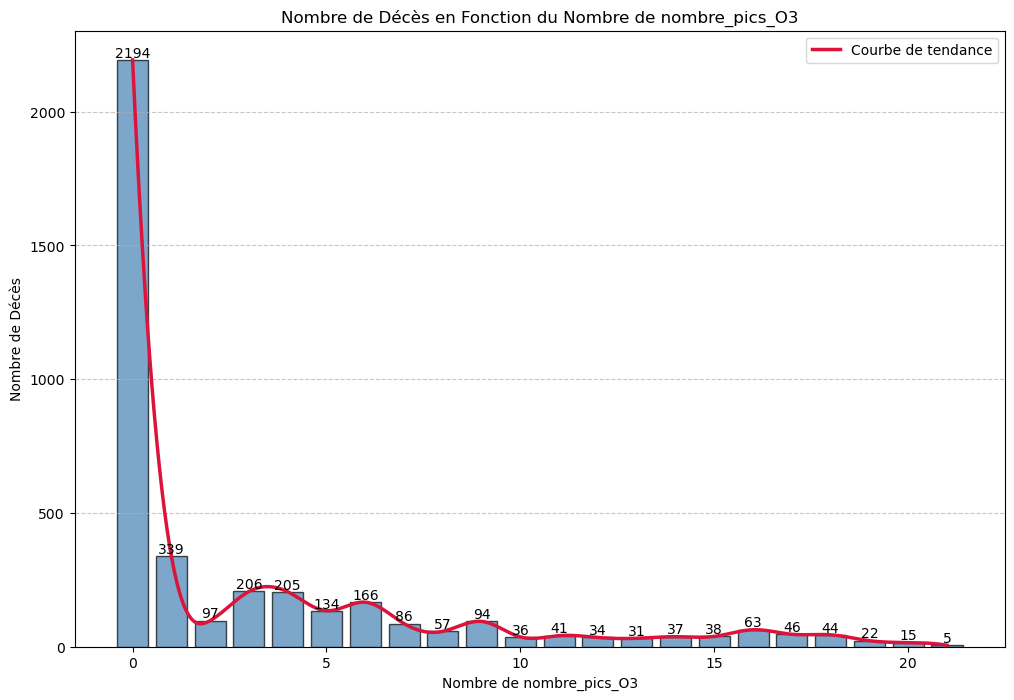

In [ ]:
# Exemple d'utilisation pour PM10 avec un seuil de 50 µg/m³
plot_deces_pic(pic_pm10_50, 'nombre_pics_PM10', 'dcd_2017_2019')

# Exemple d'utilisation pour PM10 avec un seuil de 40 µg/m³
plot_deces_pic(pic_pm10_40, 'nombre_pics_PM10', 'dcd_2017_2019')

# Exemple d'utilisation pour O3 avec un seuil de 140 µg/m³
plot_deces_pic(pic_O3_180, 'nombre_pics_O3', 'dcd_2017_2019')

# Exemple d'utilisation pour O3 avec un seuil de 140 µg/m³
plot_deces_pic(pic_O3_140, 'nombre_pics_O3', 'dcd_2017_2019')

# Analyse des jours de pics

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import geopandas as gpd

def analyze_pic_days(df_events, df_PM10s, pic_column, date_column, concentration_column, pathologies_column):
    # Convertir les dates en datetime si nécessaire
    df_events[date_column] = pd.to_datetime(df_events[date_column])

    # Extraire les jours de pic de chaque patient (en supposant que pic_column est une liste de jours de pic)
    df_events['pic_days'] = df_events[pic_column].apply(lambda x: pd.to_datetime(eval(x)) if pd.notna(x) else pd.NaT)
    
    # Développer les jours de pic en lignes individuelles
    pic_days_expanded = df_events.explode('pic_days')

    # Compter le nombre d'occurrences de chaque jour de pic
    pic_day_counts = pic_days_expanded['pic_days'].value_counts().reset_index()
    pic_day_counts.columns = ['pic_day', 'count']

    # Convertir les jours de pic en format datetime
    pic_day_counts['pic_day'] = pd.to_datetime(pic_day_counts['pic_day'])
    
    # Fusionner avec df_PM10s pour obtenir les concentrations
    df_PM10s[date_column] = pd.to_datetime(df_PM10s[date_column])
    df_concentration = pd.merge(pic_days_expanded, df_PM10s, left_on=['pseudo_provisoire', 'pic_days'], right_on=['pseudo_provisoire', date_column], how='left')
    
    # Calculer la concentration moyenne pour chaque jour de pic
    pic_day_concentration = df_concentration.groupby('pic_days')[concentration_column].mean().reset_index()
    pic_day_concentration.columns = ['pic_day', 'average_concentration']

    # Fusionner les résultats
    pic_day_stats = pd.merge(pic_day_counts, pic_day_concentration, on='pic_day')

    # Identifier les jours avec le maximum de pics
    max_pic_days = pic_day_stats.sort_values(by='count', ascending=False)
    
    # Obtenir les pathologies associées aux jours de pics les plus fréquents
    top_pic_days = max_pic_days.head(10)  # Modifier selon le nombre de jours à analyser
    top_pic_dates = top_pic_days['pic_day'].tolist()
    
    # Filtrer les données pour les jours de pic les plus fréquents
    pathologies_data = df_events[df_events['pic_days'].apply(lambda x: any(pd.to_datetime(d) in top_pic_dates for d in x))]
    
    # Extraire les pathologies associées
    pathologies_summary = pathologies_data[pathologies_column].value_counts().reset_index()
    pathologies_summary.columns = ['pathology', 'count']

    # Affichage des résultats
    print("Jours de pic les plus fréquents et leurs concentrations :")
    print(pic_day_stats)
    
    print("\nPathologies associées aux jours de pic les plus fréquents :")
    print(pathologies_summary)

    # Visualisation des résultats
    plt.figure(figsize=(12, 6))
    sns.barplot(x='pic_day', y='count', data=pic_day_stats, palette='viridis')
    plt.xticks(rotation=45)
    plt.xlabel('Jour de Pic')
    plt.ylabel('Nombre d\'Occurrences')
    plt.title('Nombre d\'Occurrences des Jours de Pic')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(x='pic_day', y='average_concentration', data=pic_day_stats, palette='viridis')
    plt.xticks(rotation=45)
    plt.xlabel('Jour de Pic')
    plt.ylabel('Concentration Moyenne')
    plt.title('Concentration Moyenne des Jours de Pic')
    plt.grid(True)
    plt.show()










In [64]:
pic_pm10_50.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'pseudo_provisoire', 'adresse',
       'codepost', 'nom_commune_postal', 'requete', 'x', 'y', 'score',
       'trust_score', 'street', 'city', 'pc_city', 'ic_city', 'code_dept',
       'dept', 'reg', 'address', 'address_has_num_init',
       'address_has_num_geoloc', 'same_city', 'hostel', 'hosted',
       'date_geoloc', 'geometry', 'CODE_IRIS', 'INSEE_REG', 'CODE_DEPT',
       'patient_sexe', 'date_naissance', 'centre', 'ageaudiag', 'cancernum',
       'date_diag', 'topo_initiale_cim10', 'topo_initialelib', 'patho',
       'patient_co', 'date_derniere_nouvelle', 'statut_deces', 'start_date',
       'nombre_pics_PM10', 'dates_pics_PM10', 'pic_pm10', 'dcd_2017_2019'],
      dtype='object')

In [ ]:
analyze_pic_days(pic_pm10_50, df_PM10s, pic_column='dates_pics_PM10', date_column='date_geoloc', concentration_column='pic_pm10', pathologies_column='patho')